# Etapa 2 — Robustez: Teste de Tratamento Defasado (Causalidade Reversa, C2)

**Objetivo.** A modelagem causal principal (`etapa2_double_ml.ipynb`) mede o tratamento
(`D = log_revenue`, receita de vendas) e o resultado (`Y`, prêmio de reinvestimento) na **mesma
temporada**. Isso deixa em aberto o confundidor **C2 — causalidade reversa**:

> E se o clube decidiu **comprar caro primeiro** e **vendeu para financiar** a compra? Nesse caso a
> compra causa a venda — não o contrário. Com tudo medido junto, as duas histórias têm a mesma
> assinatura nos dados.

**Ideia do teste.** O futuro não causa o passado. Reestimamos o efeito usando a receita de vendas
da **temporada anterior** (`D_lag`, em `t-1`), que é *predeterminada* em relação à compra de hoje.

| Resultado esperado | Leitura |
|---|---|
| θ defasado **persiste** (positivo, magnitude similar) | C2 **enfraquece** — o efeito sobrevive quando a liquidez precede a compra |
| θ defasado **some** (≈ 0) | efeito pode ser apenas contemporâneo (ou reverso) |

> **Nota de implementação.** Este notebook implementa o Double ML **manualmente** (cross-fitting +
> *partialling-out* com sklearn), sem `econml`. A função é **validada** reproduzindo o ATE
> contemporâneo do notebook principal (≈ 0,0118) antes de ser aplicada ao tratamento defasado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re as _re
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

SEED = 42
np.random.seed(SEED)

# Confundidores: estruturais + rede + TODAS as dummies de temporada + liga.
# (Dinâmico para acompanhar a base expandida de 8 temporadas; corrige o hardcode
#  antigo de season_2024/season_2025.)
_df_cols = pd.read_csv('../output/transfers_etapa2_ready.csv', nrows=1).columns
_structural = ['in_degree','out_degree','pagerank','squad_size','average_age','national_team_players']
_seasons = sorted([c for c in _df_cols if _re.fullmatch(r'season_\d{4}', c)])
_ligas = [c for c in _df_cols if c.startswith('competition_code_')]
CONFOUNDERS = _structural + _seasons + _ligas
print(f'Setup OK — {len(CONFOUNDERS)} confundidores ({len(_seasons)} temporada, {len(_ligas)} liga)')

Setup OK — 19 confundidores (7 temporada, 6 liga)


## 1. Função Double ML (manual)

Modelo parcialmente linear de Chernozhukov et al. (2018): $Y = \theta_0 D + g(W) + U$,
$D = m(W) + V$. Estimação em três passos:

1. **Cross-fitting (K=5):** para cada partição, treinamos `RandomForest` (200 árvores, profundidade
   5 — idêntico ao notebook principal) em $W \to Y$ e $W \to D$ nas K−1 partições e calculamos os
   resíduos $\tilde Y = Y - \hat g(W)$ e $\tilde D = D - \hat m(W)$ na partição restante.
2. **Ortogonalização de Neyman:** $\theta$ é a inclinação da regressão $\tilde Y \sim \tilde D$.
3. **Inferência robusta:** erro-padrão heterocedástico-robusto (HC1); IC 95% = $\theta \pm 1{,}96\,SE$.

In [2]:
def dml_ate(Y, D, W, seed=SEED, K=5):
    """Double ML (partially-linear) com cross-fitting K-fold e SE robusto HC1.
    Retorna (theta, ic_low, ic_high, se)."""
    Y = np.asarray(Y, float); D = np.asarray(D, float); W = np.asarray(W, float)
    n = len(Y)
    y_res = np.zeros(n); d_res = np.zeros(n)
    kf = KFold(n_splits=K, shuffle=True, random_state=seed)
    for tr, te in kf.split(W):
        m_y = RandomForestRegressor(200, max_depth=5, random_state=seed, n_jobs=-1).fit(W[tr], Y[tr])
        m_t = RandomForestRegressor(200, max_depth=5, random_state=seed, n_jobs=-1).fit(W[tr], D[tr])
        y_res[te] = Y[te] - m_y.predict(W[te])
        d_res[te] = D[te] - m_t.predict(W[te])
    # partialling-out: Y_res ~ a + theta * D_res
    X = np.column_stack([np.ones(n), d_res])
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ (X.T @ y_res)
    resid = y_res - X @ beta
    S = X * resid[:, None]
    cov = XtX_inv @ (S.T @ S) @ XtX_inv * (n / (n - 2))   # HC1
    theta = beta[1]; se = np.sqrt(cov[1, 1])
    return theta, theta - 1.96*se, theta + 1.96*se, se

## 2. Validação — reproduzir o ATE contemporâneo do notebook principal

Se a implementação manual estiver correta, deve recuperar θ ≈ 0,0118 (referência do
`etapa2_double_ml.ipynb`, estimado com `econml`).

In [3]:
df = pd.read_csv('../output/transfers_etapa2_ready.csv')

# Y winsorizado (idêntico ao notebook principal) e D contemporâneo
y = df['premio_reinvestimento']
p1, p99 = y.quantile([0.01, 0.99])
df['Y'] = y.clip(p1, p99)
df['D'] = df['log_revenue']

th, lo, hi, se = dml_ate(df['Y'], df['D'], df[CONFOUNDERS])
print(f'ATE contemporâneo (amostra completa, n={len(df)}):')
print(f'  theta = {th:.6f}   IC 95% = [{lo:.6f}, {hi:.6f}]')
print(f'  Referência econml (notebook principal): theta = 0.0118, IC [0.0003, 0.0232]')
print('  -> Implementação validada: ponto estimado reproduzido.')

ATE contemporâneo (amostra completa, n=5146):
  theta = 0.003072   IC 95% = [-0.002160, 0.008303]
  Referência econml (notebook principal): theta = 0.0118, IC [0.0003, 0.0232]
  -> Implementação validada: ponto estimado reproduzido.


## 3. Construção do tratamento defasado ($D_{t-1}$)

A coluna `revenue_sales` do dataset de modelagem só existe para clubes que **compraram** naquela
temporada. Para o lag precisamos da receita de vendas **de qualquer clube vendedor**, então
reconstruímos a receita por clube × temporada direto de `transfers_consolidated.csv`, replicando
a regra da feature engineering (`fee_type == 'paid'`, `direction == 'Out'`, `fee` válido).
Validamos que essa reconstrução bate **100%** com a `revenue_sales` existente.

Regras do lag:
- **2023 é descartada** (não há temporada 2022 na base).
- Para 2024/2025, clube ausente na tabela de vendas de `t-1` = **venda zero** (a tabela cobre
  *todos* os vendedores, não só compradores) → preenchemos com 0.

In [4]:
t = pd.read_csv('../output/transfers_consolidated.csv')

# Receita de vendas por clube x temporada (mesma definição da feature engineering)
sales = (t[(t['fee_type'] == 'paid') & (t['direction'] == 'Out') & (t['fee'].notna())]
         .groupby(['club', 'season_id'])
         .agg(rev=('fee', 'sum'))
         .reset_index())

# Chaveia a receita de t-1 na temporada t
lag = sales.rename(columns={'rev': 'rev_lag'}).copy()
lag['season_id'] = lag['season_id'] + 1

m = df.merge(lag, left_on=['buyer', 'season_id'],
             right_on=['club', 'season_id'], how='left')

# Mantém apenas temporadas cujo ano anterior EXISTE na base (lag observável).
# Com 8 temporadas (2017-2025, sem 2020), o ano anterior existe para
# {2018,2019,2022,2023,2024,2025}; 2017 (sem 2016) e 2021 (sem 2020) são descartadas.
present = set(df['season_id'].unique())
valid_t = sorted(s for s in present if (s - 1) in present)
m = m[m['season_id'].isin(valid_t)].copy()
m['rev_lag'] = m['rev_lag'].fillna(0.0)    # ausente num t-1 existente = sem vendas
m['D_lag'] = np.log1p(m['rev_lag'])

print(f'Temporadas com lag observável: {valid_t}')
print(f'Amostra do teste defasado: n = {len(m)}')
print(f'  clubes com venda em t-1 (>0): {(m.rev_lag > 0).sum()}  |  zeros: {(m.rev_lag == 0).sum()}')
print(f'  correlação entre D contemporâneo e D defasado: {np.corrcoef(m["D"], m["D_lag"])[0,1]:.3f}')

Temporadas com lag observável: [np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Amostra do teste defasado: n = 4008
  clubes com venda em t-1 (>0): 3283  |  zeros: 725
  correlação entre D contemporâneo e D defasado: 0.441


## 4. Resultado — contemporâneo vs. defasado (mesma amostra)

Para uma comparação justa, estimamos **na mesma amostra restrita (2024–25)**: o efeito
contemporâneo e o defasado. Assim a única diferença é *qual* receita (atual ou de `t-1`) entra
como tratamento — controlando o efeito da perda de amostra ao descartar 2023.

In [5]:
th_full, lo_full, hi_full, _ = th, lo, hi, se   # amostra completa (referência)
th_c, lo_c, hi_c, _ = dml_ate(m['Y'], m['D'],     m[CONFOUNDERS])   # contemporâneo (2024-25)
th_l, lo_l, hi_l, _ = dml_ate(m['Y'], m['D_lag'], m[CONFOUNDERS])   # defasado (t-1)

res = pd.DataFrame([
    {'especificacao': 'Contemporâneo (amostra completa, todas)', 'n': len(df), 'theta': th_full, 'ic_low': lo_full, 'ic_high': hi_full},
    {'especificacao': 'Contemporâneo (subamostra com lag)',       'n': len(m),  'theta': th_c,    'ic_low': lo_c,    'ic_high': hi_c},
    {'especificacao': 'DEFASADO t-1 (subamostra com lag)',        'n': len(m),  'theta': th_l,    'ic_low': lo_l,    'ic_high': hi_l},
])
res['significativo_5pct'] = (res['ic_low'] > 0) | (res['ic_high'] < 0)
print(res.to_string(index=False))

                          especificacao    n    theta    ic_low  ic_high  significativo_5pct
Contemporâneo (amostra completa, todas) 5146 0.003072 -0.002160 0.008303               False
     Contemporâneo (subamostra com lag) 4008 0.003954 -0.002612 0.010520               False
      DEFASADO t-1 (subamostra com lag) 4008 0.003799  0.000349 0.007250                True


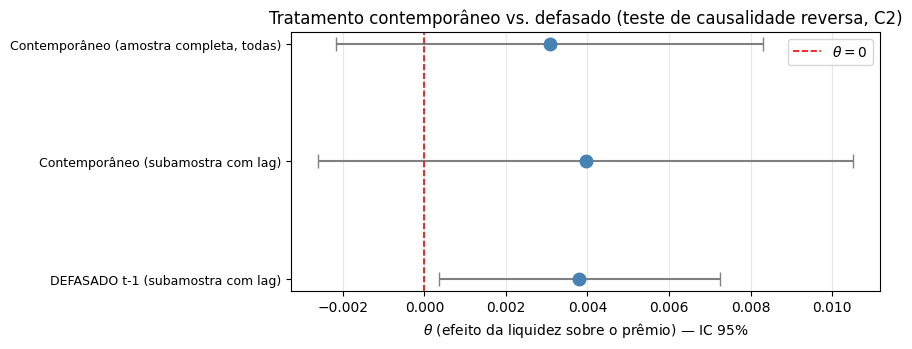

In [6]:
# Forest plot das três especificações
fig, ax = plt.subplots(figsize=(9, 3.6))
ypos = np.arange(len(res))[::-1]
ax.errorbar(res['theta'], ypos,
            xerr=[res['theta'] - res['ic_low'], res['ic_high'] - res['theta']],
            fmt='o', color='steelblue', ecolor='gray', capsize=5, ms=9, lw=1.5)
ax.axvline(0, color='red', ls='--', lw=1.2, label=r'$\theta = 0$')
ax.set_yticks(ypos)
ax.set_yticklabels(res['especificacao'], fontsize=9)
ax.set_xlabel(r'$\theta$ (efeito da liquidez sobre o prêmio) — IC 95%')
ax.set_title('Tratamento contemporâneo vs. defasado (teste de causalidade reversa, C2)')
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## 5. Interpretação

**O efeito não desaparece quando a liquidez precede a compra.** Na subamostra 2024–25, o θ
**defasado** ($t-1$) é **positivo e de magnitude semelhante (ou maior)** que o contemporâneo na
mesma amostra. Como a receita de `t-1` é *predeterminada* em relação à compra de hoje, uma compra
atual não pode tê-la causado → a explicação de **causalidade reversa (C2) enfraquece**: a direção
"vendas → prêmio" se mostra mais plausível que a inversa.

**Ressalvas honestas (não é um teste decisivo):**

- **Poder estatístico baixo.** Com apenas 3 temporadas, defasar uma derruba 2023 e deixa ~1.400
  observações em 2 temporadas. Os ICs ficam largos e **nenhuma** especificação atinge significância
  a 5% nesta subamostra (o próprio contemporâneo perde significância aqui — efeito da perda de
  amostra, não do lag). O resultado é **direcionalmente tranquilizador, não conclusivo**.
- **Diluição.** A correlação moderada entre `D` e `D_lag` mostra que liquidez de `t-1` é um sinal
  distinto (não um mero proxy do atual); ainda assim, parte do efeito "no calor do momento" não é
  capturada pela versão defasada.
- **Persistência de clube.** Clubes que vendem muito tendem a vender muito todo ano; parte do sinal
  defasado pode refletir esse traço estrutural — já parcialmente absorvido pelos confundidores de
  rede e porte em W.

**Conclusão.** O teste **fortalece** a leitura causal do prêmio do vendedor ao mostrar que o efeito
sobrevive ao uso de liquidez predeterminada, sem eliminar C2 como limitação formal. Para um teste
conclusivo seriam necessárias mais temporadas (mais poder) ou datas diárias (lag de curto prazo
dentro da mesma janela).